In [1]:
# Autoencoder for Image Denoising using PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torchsummary import summary

In [2]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Transform: Normalize and convert to tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

In [22]:
# Load MNIST dataset
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [23]:
# Print the first 50 labels from the training dataset
labels = dataset.targets[:50].numpy()
print('First 50 Labels in MNIST Train Dataset:')
print(labels)

First 50 Labels in MNIST Train Dataset:
[5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9 4 0 9 1 1 2 4 3 2 7 3 8 6 9 0 5 6
 0 7 6 1 8 7 9 3 9 8 5 9 3]


In [24]:
# Alternatively, inspect a batch from the DataLoader
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(f'Batch Image Shape: {images.shape}')
print(f'Batch Labels: {labels[:10]}')

Batch Image Shape: torch.Size([128, 1, 28, 28])
Batch Labels: tensor([1, 4, 1, 0, 7, 4, 3, 4, 6, 2])


In [5]:
# Add noise to images
def add_noise(inputs, noise_factor=0.5):
    noisy = inputs + noise_factor * torch.randn_like(inputs)
    return torch.clamp(noisy, 0., 1.)


In [6]:
from torch.nn.modules.conv import ConvTranspose2d
# Define Autoencoder
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
      super(DenoisingAutoencoder, self).__init__()
      self.encoder = nn.Sequential(
          nn.Conv2d(1, 16, kernel_size = 3, stride = 2, padding = 1),
          nn.ReLU(),
          nn.Conv2d(16, 32, kernel_size = 3, stride = 2, padding =1),
          nn.ReLU()
      )

      self.decoder = nn.Sequential(
          nn.ConvTranspose2d(32, 16, kernel_size = 2, stride = 2),
          nn.ReLU(),
          nn.ConvTranspose2d(16, 1, kernel_size = 2, stride = 2)
      )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [7]:
# Re-initialize model with the fixed architecture, loss function and optimizer
model = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

In [8]:
# Print model summary
print('Name: Surya Prakash B')
print('Register Number: 212224230281')
summary(model, input_size=(1, 28, 28))

Name: Surya Prakash B
Register Number: 212224230281
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 14, 14]             160
              ReLU-2           [-1, 16, 14, 14]               0
            Conv2d-3             [-1, 32, 7, 7]           4,640
              ReLU-4             [-1, 32, 7, 7]               0
   ConvTranspose2d-5           [-1, 16, 14, 14]           2,064
              ReLU-6           [-1, 16, 14, 14]               0
   ConvTranspose2d-7            [-1, 1, 28, 28]              65
Total params: 6,929
Trainable params: 6,929
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.13
Params size (MB): 0.03
Estimated Total Size (MB): 0.16
----------------------------------------------------------------


In [15]:
# Train the autoencoder
def train(model, loader, criterion, optimizer, epochs=5):
  model.train()
  print('Name: Surya Prakash B')
  print('Register Number: 212224230281')
  for epoch in range(epochs):
        running_loss = 0.0
        for images, _ in loader:
            images = images.to(device)
            noisy_images = add_noise(images).to(device)

            outputs = model(noisy_images)
            loss = criterion(outputs, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(loader):.4f}")

In [16]:
# Evaluate and visualize
def visualize_denoising(model, loader, num_images=10):
    model.eval()
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            noisy_images = add_noise(images).to(device)
            outputs = model(noisy_images)
            break

    images = images.cpu().numpy()
    noisy_images = noisy_images.cpu().numpy()
    outputs = outputs.cpu().numpy()

    print('Name: Surya Prakash B')
    print('Register Number: 212224230281')
    plt.figure(figsize=(18, 6))

    for i in range(num_images):
        # Original
        ax = plt.subplot(3, num_images, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        ax.set_title("Original")
        plt.axis("off")

        # Noise
        ax = plt.subplot(3, num_images, i + 1 + num_images)
        plt.imshow(noisy_images[i].squeeze(), cmap='gray')
        ax.set_title("Noisy")
        plt.axis("off")

        # Denoise
        ax = plt.subplot(3, num_images, i + 1 + 2 * num_images)
        plt.imshow(outputs[i].squeeze(), cmap='gray')
        ax.set_title("Denoised")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Name: Surya Prakash B
Register Number: 212224230281
Epoch [1/5], Loss: 0.0198
Epoch [2/5], Loss: 0.0196
Epoch [3/5], Loss: 0.0195
Epoch [4/5], Loss: 0.0194
Epoch [5/5], Loss: 0.0193
Name: Surya Prakash B
Register Number: 212224230281


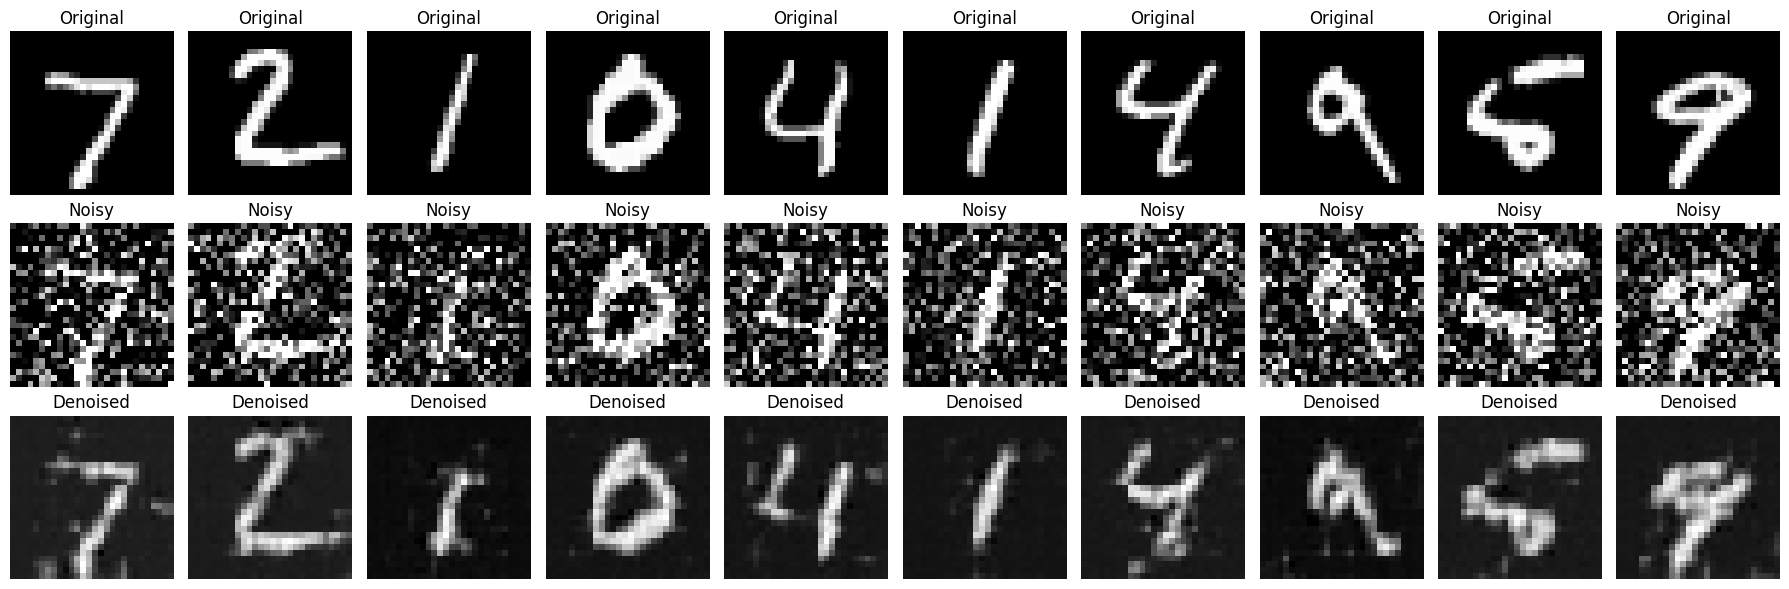

In [17]:
# Run training and visualization with the fixed model
train(model, train_loader, criterion, optimizer, epochs = 5)
visualize_denoising(model, test_loader)